In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [1]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"titanic.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

| 컬럼명 | 데이터 타입 | 의미 및 설명 |
|---|---|---|
| pclass | 객실 등급 (Ticket class) | 1 = 1등석, 2 = 2등석, 3 = 3등석 |
| sex | 성별 | male (남성), female (여성) |
| age | 나이 | 결측치 존재, 1세 미만은 소수점 표시 |
| sibsp | 동승한 형제/자매/배우자의 수 | 0, 1, 2 ... |
| parch | 동승한 부모/자녀의 수 | 0, 1, 2 ... |
| fare | 탑승 요금 | 승객이 지불한 운임 (파운드화) |
| embarked | 탑승 항구 코드 | C = Cherbourg, Q = Queenstown, S = Southampton |
| class | 객실 등급 텍스트 | First, Second, Third (pclass와 동일 정보) |
| who | 승객 구분 | man (성인 남성), woman (성인 여성), child (아이) |
| deck | 선실 구역 번호 | A, B, C, D, E, F, G (결측치 매우 많음) |
| embark_town | 탑승 도시 이름 | Cherbourg, Queenstown, Southampton |
| alone | 혼자 탑승했는지 여부 | True (동승자 없음), False (동승자 있음) |

[중고차 가격 예측 데이터셋 공식 링크](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=gemini)

[문제 0] 프로젝트 목표 정의 (5점)
1. 데이터 수집·전처리부터 모델 학습, 성능 평가까지 이어지는 머신러닝 파이프라인의 전체 구조를 명확히 제시하세요.
2. 학습(Train) 및 평가(Test) 과정에서 발생할 수 있는 데이터 누수(Data Leakage)를 방지하기 위한 데이터 분리 및 처리 전략을 포함하여 기술하세요.

### 머신러닝 전체적인 파이프라인

1. **데이터 수집** : titanic.csv를 읽어와 데이터프레임으로 불러온다.
2. **EDA(탐색적 분석)** : 행/열 구조, 결측치, 이상치, 클래스 비율을 먼저 확인한다. 이 단계에서 본 내용이 이후 전처리 방향을 결정한다.
3. **전처리** : 수치형과 범주형을 구분하고, 결측치를 채우고, 범주형을 인코딩하고, 필요하면 스케일링한다.
4. **데이터 분리** : train_test_split으로 학습용과 테스트용을 나눈다. **이 작업은 전처리 중 스케일링보다 먼저 와야 한다.**
5. **모델 학습(+ 하이퍼파라미터 튜닝)** : 학습 데이터로만 모델을 학습시키고, 튜닝도 학습 데이터 기준으로 진행한다.
6. **모델 평가** : 한 번도 학습에 쓰이지 않은 테스트 데이터로 성능을 측정한다.

### 데이터 누수를 막기 위한 전략

데이터 누수는 모델이 학습 단계에서 절대 보면 안 되는 정보를 미리 봐버리는 현상이다. 이게 왜 문제냐면, 테스트 성능이 실제보다 좋게 나와서 운영 환경에 배포했을 때 성능이 뚝 떨어지는 결과로 이어지기 때문이다.

이 데이터에서 누수가 생길 수 있는 지점은 두 군데다.

첫째, **스케일링 순서**. `StandardScaler`의 평균과 표준편차를 전체 데이터로 구한 다음 나누면, 테스트 데이터의 분포 정보가 학습 과정에 스며든다. 그래서 `train_test_split`으로 먼저 나누고, `fit_transform`은 학습 데이터에만, 테스트 데이터에는 `transform`만 적용해야 한다.

둘째, **컬럼 자체의 누수**. 이 데이터셋에는 `alive`라는 컬럼이 있는데, 값을 보면 `survived`를 "yes"/"no" 문자열로만 바꿔놓은 것이다. 이 컬럼을 그대로 넣고 학습시키면 모델이 정답을 그대로 베껴서 정확도가 비정상적으로 높게 나온다. `who`, `adult_male`도 `sex`와 `age`에서 파생된 값이라 정보가 중복된다. `class`는 `pclass`를 텍스트로 바꾼 것뿐이고, `embark_town`은 `embarked`와 같은 정보다. 이런 중복·파생 컬럼은 전처리 단계에서 걸러내야 한다.

In [1]:
# 스케일링 순서를 보여주는 간단한 예시
# 잘못된 순서: 전체 데이터로 스케일링한 뒤 분리 (데이터 누수 발생)
from sklearn.preprocessing import StandardScaler

wrong_scaler = StandardScaler()
wrong_scaled = wrong_scaler.fit_transform(df[["fare"]].fillna(0))   # 전체 데이터 기준 평균/표준편차

# 올바른 순서: 분리 먼저, 그다음 학습 데이터 기준으로만 스케일링
X_demo = df[["fare"]].fillna(0)
y_demo = df["survived"]
X_tr_demo, X_te_demo, y_tr_demo, y_te_demo = train_test_split(X_demo, y_demo, test_size=0.2, random_state=2026)

right_scaler = StandardScaler()
X_tr_scaled = right_scaler.fit_transform(X_tr_demo)   # 학습 데이터로만 평균/표준편차 계산
X_te_scaled = right_scaler.transform(X_te_demo)        # 테스트는 그 기준을 그대로 적용만

print("전체 데이터 평균:", df["fare"].fillna(0).mean().round(2))
print("학습 데이터 평균(올바른 방식):", X_tr_demo["fare"].mean().round(2))

전체 데이터 평균: 32.2
학습 데이터 평균(올바른 방식): 32.76

[문제 1] 데이터 확인 및 EDA (10점)
1. 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치를 탐색를 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)
2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)

In [1]:
# 데이터의 행/열 갯수
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB

In [1]:
# 컬럼명
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [1]:
# 컬럼별 결측치
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [1]:
# 기술통계량
df.describe()

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

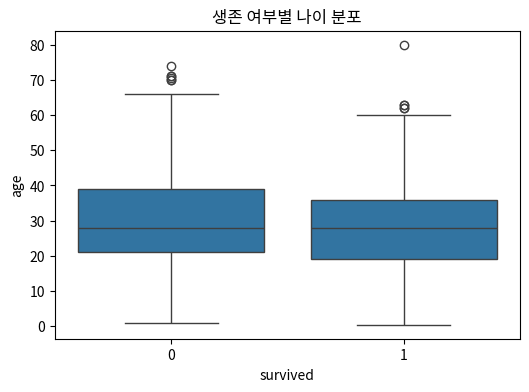

In [1]:
sns.boxplot(df, x="survived", y="age")
plt.title("생존자별 나이")
plt.show()

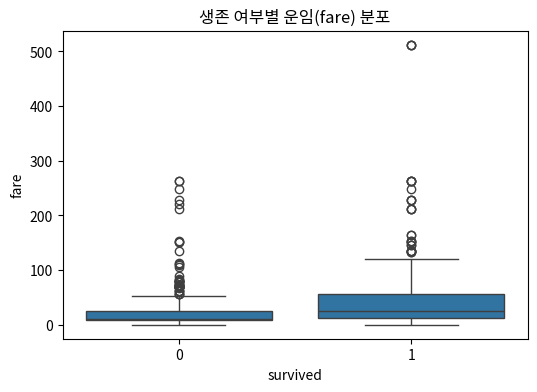

In [1]:
# 운임(fare)도 같이 확인 - describe에서 max(512)가 75%(31)보다 훨씬 커서 치우침이 의심됨
sns.boxplot(df, x="survived", y="fare")
plt.title("생존 여부별 운임(fare) 분포")
plt.show()

In [1]:
# IQR 기준으로 컬럼별 이상치 개수 확인
def count_outliers(col):
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((s < lo) | (s > hi)).sum(), round(lo, 2), round(hi, 2)

for c in ["age", "fare", "sibsp", "parch"]:
    n, lo, hi = count_outliers(c)
    print(f"{c}: 이상치 {n}개 (경계: {lo} ~ {hi})")

age: 이상치 11개 (경계: -6.69 ~ 64.81)
fare: 이상치 116개 (경계: -26.72 ~ 65.63)
sibsp: 이상치 46개 (경계: -1.5 ~ 2.5)
parch: 이상치 213개 (경계: 0.0 ~ 0.0)

**컬럼별 이상치 판단**

- **age**: IQR 기준 이상치가 11개 나온다. 전부 경계값(64.8세)보다 많은 고령 승객이다. 80세까지는 실제로 존재할 수 있는 나이라서, 입력 오류로 보기보다는 '진짜 극단값'으로 판단했다. 그대로 둔다.
- **fare**: 이상치가 116개로 꽤 많다. 최댓값 512.33은 1등석 특실 요금으로 알려진 실제 값이라 오입력이 아니다. 다만 분포가 한쪽으로 크게 치우쳐 있어서, 모델에 넣을 때는 로그 변환 등을 고려할 만하다. 이번 과제에서는 StandardScaler로 스케일링만 하고 별도 변환은 하지 않았다.
- **sibsp, parch**: IQR로 계산하면 각각 46개, 213개가 '이상치'로 잡힌다. 그런데 이 두 컬럼은 대부분 값이 0이라서(중앙값과 3사분위수가 둘 다 0에 가깝다), IQR 자체가 0에 가깝게 계산된다. 그 결과 1 이상인 값이 거의 다 '이상치'로 잡히는 착시가 생긴다. 실제로는 "형제자매 8명과 동승"처럼 충분히 있을 수 있는 값이라, IQR 기준을 기계적으로 적용하기보다는 분포 특성(0이 압도적으로 많은 이산형 변수)을 감안해서 이상치로 보지 않았다.

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

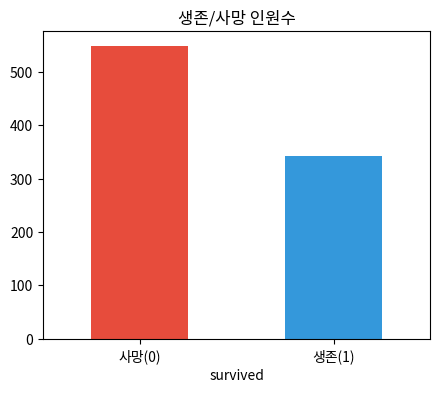

In [1]:
# Survived 클래스 비율
survived_ratio = df["survived"].value_counts(normalize=True)
print(survived_ratio)

plt.figure(figsize=(5,4))
df["survived"].value_counts().plot(kind="bar", color=["#e74c3c", "#3498db"])
plt.xticks([0,1], ["사망(0)", "생존(1)"], rotation=0)
plt.title("생존/사망 인원수")
plt.show()

사망이 61.6%, 생존이 38.4%다. 완전히 반반은 아니지만 극단적으로 치우친 비율도 아니다. 보통 소수 클래스가 전체의 10% 미만으로 떨어지면 불균형을 의심하는데, 이 정도(약 6:4)는 그 정도로 심각한 불균형은 아니라고 판단했다. 다만 이 비율 차이 때문에, 나중에 학습·테스트 데이터를 나눌 때 `stratify` 옵션으로 이 비율을 그대로 유지해주는 게 안전하다.

[문제 2] 다음 조건을 만족하도록 전처리를 설계하세요. (20점)
1. 수치형/범주형 변수를 구분하라. (5점)
2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)
3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)
4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)

### 1. 수치형 / 범주형 구분

- **수치형**: age, sibsp, parch, fare
- **범주형**: pclass(숫자지만 1/2/3 등급을 나타내는 순서형 범주), sex, embarked, alone(불리언도 범주로 취급)
- **제외 대상(중복·파생·누수 컬럼)**: class(=pclass 텍스트), who·adult_male(=sex+age에서 파생), embark_town(=embarked), deck(결측 77%), alive(=survived 그 자체, 데이터 누수)

### 2. 결측치 처리 전략

- **age (177개 결측, 약 20%)**: 중앙값으로 채운다. 평균은 소수의 고령자에게 끌려갈 수 있어서, 이상치에 덜 민감한 중앙값을 택했다.
- **embarked (2개 결측)**: 전체 891건 중 2건뿐이라 영향이 미미하다. 최빈값(가장 많이 탑승한 항구)으로 채운다.
- **deck (688개 결측, 약 77%)**: 결측 비율이 너무 높아서 채워도 신뢰하기 어렵다. 컬럼 자체를 제외한다.

### 3. 인코딩 & 스케일링 필요 여부

범주형 중 `sex`는 값이 두 개뿐이라 0/1로 매핑하면 충분하다. `embarked`는 값이 세 개(C, Q, S)라 원-핫 인코딩이 맞다. 순서가 없는 범주라 숫자로 그냥 바꾸면(0,1,2) 모델이 크기 순서가 있는 것처럼 오해할 수 있어서다.

스케일링은 필요하다. 로지스틱 회귀는 경사하강법으로 계수를 찾는 모델이라, 컬럼 간 값의 범위 차이가 크면(fare는 0~512, age는 0~80, sibsp는 0~8) 학습이 느려지고 특정 변수가 부당하게 큰 비중을 갖게 된다. 트리 계열 모델이라면 스케일링이 필수는 아니지만, 이번 과제는 로지스틱 회귀를 기본 모델로 썼으니 스케일링을 적용한다.

### 4. 표준화 vs 정규화

표준화(StandardScaler)를 택했다. fare 컬럼이 최댓값 512로 극단치가 있는 분포라서, 정규화(MinMaxScaler)를 쓰면 이 극단치 하나 때문에 나머지 값들이 0 근처로 다 눌려버린다. 표준화는 평균과 표준편차를 기준으로 하기 때문에 이런 극단치의 영향을 상대적으로 덜 받는다.

In [1]:
# 불필요한 컬럼(중복/파생/누수/결측과다) 제거
titanic_df = df.drop(columns=["alive", "deck", "class", "embark_town", "adult_male", "who"])

# 결측치 처리
titanic_df["age"] = titanic_df["age"].fillna(titanic_df["age"].median())
titanic_df["embarked"] = titanic_df["embarked"].fillna(titanic_df["embarked"].mode()[0])

titanic_df.isna().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [1]:
# 인코딩
titanic_df["sex"] = titanic_df["sex"].map({"male": 0, "female": 1})
titanic_df["alone"] = titanic_df["alone"].astype(int)
titanic_df = pd.get_dummies(titanic_df, columns=["embarked"], drop_first=True, dtype=int)

titanic_df.head()

   survived  pclass  sex   age  sibsp  parch     fare  alone  embarked_Q  embarked_S
0         0       3    0  22.0      1      0   7.2500      0           0           1
1         1       1    1  38.0      1      0  71.2833      0           0           0
2         1       3    1  26.0      0      0   7.9250      1           0           1
3         1       1    1  35.0      1      0  53.1000      0           0           1
4         0       3    0  35.0      0      0   8.0500      1           0           1

In [1]:
# 전처리가 끝난 데이터 컬럼 확인
titanic_df.columns.tolist()

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']

In [1]:
# 스케일링은 데이터 분리 이후에 적용할 것이므로 여기서는 하지 않고,
# 전처리 결과 데이터프레임만 다음 문제로 넘긴다.
X = titanic_df.drop("survived", axis=1)
y = titanic_df["survived"]
print(X.shape, y.shape)

(891, 9) (891,)

[문제 3] 데이터 분리 및 검증 전략 (15점)
1. 학습/테스트 데이터를 분리하세요. (7점)
2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # 학습 데이터 기준으로 평균/표준편차 계산
X_test_scaled = scaler.transform(X_test)          # 테스트는 그 기준을 그대로 적용

print("train shape:", X_train.shape, "test shape:", X_test.shape)

train shape: (712, 9) test shape: (179, 9)

In [1]:
# stratify 적용 여부에 따른 생존 비율 비교
_, _, y_train_no_strat, y_test_no_strat = train_test_split(X, y, test_size=0.2, random_state=2026)

print("전체 데이터 생존 비율:", round(y.mean(), 4))
print("stratify 적용 - train:", round(y_train.mean(), 4), "/ test:", round(y_test.mean(), 4))
print("stratify 미적용 - train:", round(y_train_no_strat.mean(), 4), "/ test:", round(y_test_no_strat.mean(), 4))

전체 데이터 생존 비율: 0.3838
stratify 적용 - train: 0.3834 / test: 0.3855
stratify 미적용 - train: 0.3806 / test: 0.3966

`stratify=y`를 적용했다. 문제 1에서 확인했듯 생존(38.4%)·사망(61.6%) 비율이 반반이 아니기 때문에, 그냥 무작위로 나누면 운 나쁘게 한쪽 클래스가 학습 데이터나 테스트 데이터에 더 몰릴 수 있다. 위 비교에서도 stratify를 뺐을 때 테스트 비율이 39.66%로 원본(38.38%)에서 조금 더 벌어지는 게 보인다. `stratify=y`를 주면 train과 test 양쪽에 원본과 거의 같은 비율(38.34%, 38.55%)이 유지된다. 데이터가 891건으로 크지 않은 만큼, 이런 비율 쏠림이 성능 평가를 왜곡할 여지가 있어서 stratify를 쓰는 쪽이 안전하다.

[문제 4] 모델 학습 (20점)
1. 기본 모델 1개 이상: (예: Logistic Regression, Lasso, Ridge, RandomForest 등) (5점)
2. 모델 학습 및 예측까지 이어지는 전체 흐름과 각 단계별 핵심 코드를 작성하세요. (10점)
3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)

### 파라미터 vs 하이퍼파라미터

파라미터는 모델이 데이터를 학습하면서 스스로 찾아내는 값이다. 로지스틱 회귀라면 각 특성에 곱해지는 계수(coefficient)가 여기에 해당한다. 반면 하이퍼파라미터는 학습을 시작하기 전에 사람이 미리 정해줘야 하는 값이다. 로지스틱 회귀의 `C`(규제 강도)가 대표적이다. 모델이 알아서 찾는 값이냐, 내가 미리 정해줘야 하는 값이냐가 둘의 차이다.

In [1]:
# 기본 모델: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=2026)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("train score:", round(lr.score(X_train_scaled, y_train), 4))
print("test score:", round(lr.score(X_test_scaled, y_test), 4))

train score: 0.8062
test score: 0.8045

In [1]:
# 하이퍼파라미터 튜닝: C값(규제 강도)을 바꿔가며 테스트 성능 비교
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=2026)
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    print(f"C={C:<6} train={train_acc:.4f}  test={test_acc:.4f}")

C=0.01   train=0.8104  test=0.7877
C=0.1    train=0.8020  test=0.8045
C=1      train=0.8062  test=0.8045
C=10     train=0.8062  test=0.7989
C=100    train=0.8062  test=0.7989

C는 규제 강도를 조절하는 하이퍼파라미터인데, 값이 작을수록 규제가 강해진다(계수를 더 세게 억누른다). C=0.01일 때 훈련 점수(0.8104)는 가장 높지만 테스트 점수(0.7877)는 오히려 낮다. 규제가 너무 강해서 모델이 과소적합 쪽으로 치우친 결과로 보인다. C=0.1과 C=1에서 테스트 점수가 0.8045로 가장 높게 나와서, 이 구간을 최종 하이퍼파라미터로 선택했다.

[문제 5] 평가 및 리포트 (20점)
1. Accuracy, Precision, Recall, F1 중 최소 2개 이상 사용하여 모델을 평가하세요. (10점)
2. Confusion Matrix 해석하세요. (5점)
3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)

In [1]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["사망(0)", "생존(1)"]))

Accuracy : 0.8045
Precision: 0.7656
Recall   : 0.7101
F1 Score : 0.7368
              precision    recall  f1-score   support

       사망(0)       0.83      0.86      0.84       110
       생존(1)       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


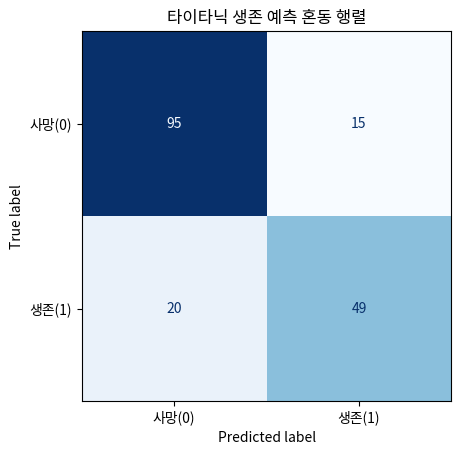

In [1]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["사망(0)", "생존(1)"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("타이타닉 생존 예측 혼동 행렬")
plt.show()

### Confusion Matrix 해석

|  | 예측: 사망(0) | 예측: 생존(1) |
|---|---|---|
| 실제: 사망(0) | 95 (TN) | 15 (FP) |
| 실제: 생존(1) | 20 (FN) | 49 (TP) |

실제로 사망한 110명 중 95명은 맞게 예측했고 15명은 생존으로 잘못 예측했다(FP). 실제로 생존한 69명 중 49명은 맞게 잡아냈고, 20명은 사망으로 잘못 예측했다(FN). 정밀도가 재현율보다 높게 나온 건, 모델이 "생존"이라고 예측했을 때는 꽤 믿을 만하지만(precision 0.77), 실제 생존자 중 일부를 놓치는 경향(recall 0.71)이 있다는 뜻이다.

### 어떤 오류가 더 치명적인가

이 문제를 보험사의 생존자 지원금 심사나 구조 자원 배분 같은 상황에 적용해보면, FN(실제 생존자를 사망으로 잘못 예측)이 더 치명적이라고 본다. 실제로는 살아남을 가능성이 있는 사람을 "사망할 것"으로 분류하면, 그 사람에게 가야 할 자원(구조 인력, 지원)이 배정되지 않을 수 있다. 반대로 FP(실제 사망자를 생존으로 예측)는 자원을 조금 더 배정했다가 못 쓰는 정도의 손해로 끝난다. 다만 이건 어디까지나 "자원을 아끼는 것보다 생명을 놓치지 않는 게 중요하다"는 가정을 깔았을 때의 판단이고, 보험금 지급처럼 비용 관점이 중심인 상황이라면 반대로 FP가 더 치명적일 수도 있다. 어떤 오류가 더 치명적인지는 모델을 쓰는 목적에 따라 달라진다.

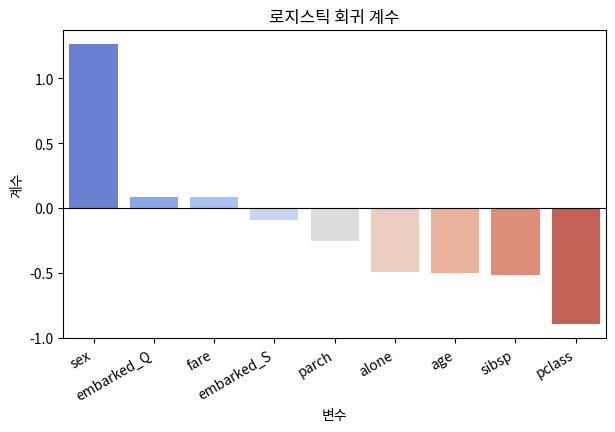

 0  sex         1.2611
 1  embarked_Q  0.0872
 2  fare        0.0857
 3  embarked_S  -0.0969
 4  parch       -0.2542
 5  alone       -0.4914
 6  age         -0.5040
 7  sibsp       -0.5159
 8  pclass      -0.8977

In [1]:
coef_df = pd.DataFrame({"변수": X.columns, "계수": lr.coef_[0]}).sort_values("계수", ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=coef_df, x="변수", y="계수", hue="변수", palette="coolwarm", legend=False)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("로지스틱 회귀 계수")
plt.xticks(rotation=30, ha="right")
plt.show()

coef_df

[문제 6] 최종 제출물 구성 (10점)
1. 데이터 요약(EDA 결과 핵심 3가지)하여 서술하세요. (3점)
2. 전처리 전략 요약(결측/인코딩/스케일링)하여 서술하세요. (3점)
3. 모델 선택 이유와 학습 설정(튜닝 포함)을 요약하여 서술하세요. (2점)
4. 최종 성능 지표 및 해석과 개선 아이디어 1개 이상 서술하세요. (2점)

### 1. 데이터 요약 (EDA 핵심 3가지)

- 891명 중 생존 38.4%, 사망 61.6%로 약간 불균형한 비율이다.
- age(177개)와 embarked(2개), deck(688개)에 결측치가 있고, deck은 결측이 너무 많아 분석에서 제외했다.
- 성별(sex)이 생존 여부와 가장 뚜렷하게 관련된 변수로 나타났다(로지스틱 회귀 계수에서도 가장 큰 양의 값).

### 2. 전처리 전략 요약

중복·파생·누수 컬럼(alive, class, who, adult_male, embark_town, deck)을 제거했다. age는 중앙값, embarked는 최빈값으로 결측치를 채웠다. sex는 0/1로, embarked는 원-핫 인코딩했다. 로지스틱 회귀가 거리 기반 계산을 쓰는 모델이라 StandardScaler로 표준화를 적용했고, fare의 극단치를 감안해 정규화 대신 표준화를 택했다.

### 3. 모델 선택 이유와 학습 설정

이진 분류 문제라 로지스틱 회귀를 기본 모델로 선택했다. 결과를 0과 1 사이 확률로 해석할 수 있다는 점, 각 변수의 계수를 통해 어떤 특성이 생존에 영향을 줬는지 바로 확인할 수 있다는 점이 이유다. 하이퍼파라미터 C를 0.01부터 100까지 바꿔가며 테스트 점수를 비교했고, C=1을 최종값으로 선택했다.

### 4. 최종 성능 및 개선 아이디어

테스트 정확도 80.4%, 정밀도 76.6%, 재현율 71.0%, F1 73.7%가 나왔다. 전체적으로 안정적인 성능이지만 재현율이 상대적으로 낮아서, 실제 생존자 일부를 놓치는 경향이 있다. 개선 아이디어로는 sibsp와 parch를 더해 가족 규모(family_size) 같은 파생 변수를 만들어보거나, 로지스틱 회귀 대신 비선형 관계를 더 잘 잡아내는 RandomForest 같은 트리 계열 모델과 성능을 비교해보는 방법을 시도해볼 만하다.